In [ ]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# Image-Conditioned Autoregressive Molecule Generation
Build base graphs under a fixed, immutable interpretation graph context.


In [1]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import warnings


In [2]:
def estimated_predictive_performance(train_graphs, train_targets, test_graphs, test_targets):
    from NSPPK.nsppk import NSPPK
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)
    train_X = vectorizer.transform(train_graphs)
    test_X = vectorizer.transform(test_graphs)
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
    clf.fit(train_X, train_targets)
    from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
    y_prob = clf.predict_proba(test_X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(test_targets, y_pred)
    print(f'Test accuracy: {acc:.3f} | ROC-AUC: {roc_auc_score(test_targets, y_prob):.3f} | AvgPrec: {average_precision_score(test_targets, y_prob):.3f}')

In [3]:
def estimated_generative_quality(generated_graphs, generated_targets, train_graphs, train_targets, reference_graphs, reference_targets, test_graphs, test_targets):
    from NSPPK.nsppk import NSPPK
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)

    from sklearn.ensemble import ExtraTreesClassifier
    classifier = ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42)

    from abstractgraph_generative.generative_performance import compute_expected_gain_weighted_equivalent_data_size
    results = compute_expected_gain_weighted_equivalent_data_size(
        generated_graphs, generated_targets, train_graphs, train_targets, reference_graphs, reference_targets, test_graphs, test_targets,
        vectorizer=vectorizer, classifier=classifier,
        fracional_size=(1,2,3,4,5,7,10,15),
        n_repeats=30,
    )
    print(f'Expected gain weighted equivalent data size:{results["expected_gain_weighted_equivalent_data_size"]:.3f}')

    from abstractgraph_generative.generative_performance import plot_expected_gain_weighted_equivalent_data_size
    _ = plot_expected_gain_weighted_equivalent_data_size(results)

---

size: 7878


[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 75 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 65 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 55 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[10:59:32] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom

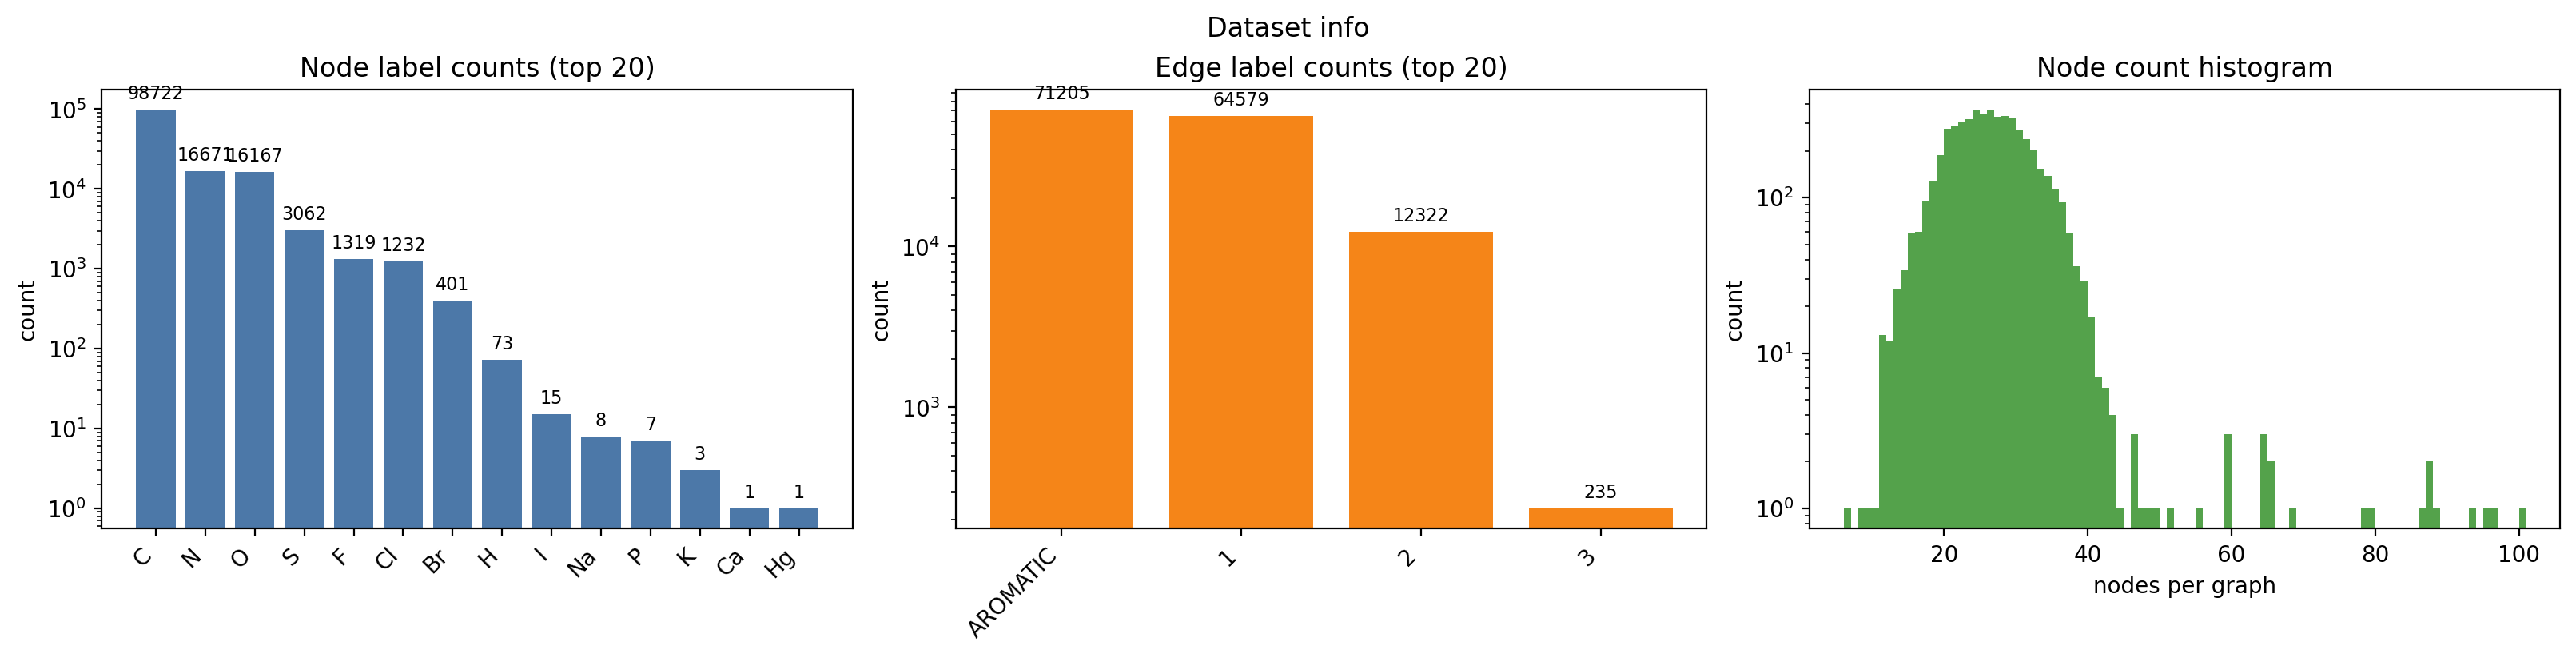

In [4]:
from abstractgraph_graphicalizer.chem import PubChemLoader

loader = PubChemLoader(on_error="skip")

assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_id = assay_ids[1]
assay_id = '624249' #bundled-safe assay example
size = int(2600/.33) #to account for 0.33 for test and 0.5 for reference
print(f"size: {size}")
use_equalized = True


limit_active = int(size // 2) if use_equalized else int(size)
limit_inactive = int(size // 2) if use_equalized else int(size)
graphs, targets = loader.load(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)
targets = np.array(targets)

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)


In [ ]:
from sklearn.model_selection import train_test_split
test_size = 0.33
all_train_graphs, test_graphs, all_train_targets, test_targets = train_test_split(
    graphs,
    targets,
    test_size=test_size,
    stratify=targets if len(np.unique(targets)) > 1 else None,
    random_state=0,
)
reference_split_size = 0.5
train_graphs, reference_graphs, train_targets, reference_targets = train_test_split(
    all_train_graphs,
    all_train_targets,
    test_size=reference_split_size,
    stratify=all_train_targets if len(np.unique(all_train_targets)) > 1 else None,
    random_state=0,
)
print(f"AID {assay_id} graphs: {len(graphs)} (train={len(train_graphs)}, reference={len(reference_graphs)}, test={len(test_graphs)})")
#estimated_predictive_performance(train_graphs, train_targets, test_graphs, test_targets)

---

In [6]:
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph.operators import *
from abstractgraph_ml.feasibility import FeasibilityEstimatorFeatureCannotExist, FeasibilityEstimator
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph_generative.conditional import (
    ConditionalAutoregressiveGenerator,
)
from abstractgraph_generative.legacy.conditional_v0_1 import (
    display_conditioned_graphs,
)

df = compose(neighborhood(radius=2), unlabel())
fe1 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
df = add(neighborhood(radius=1), cycle())
fe2 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
feasibility_estimators = [fe1, fe2]
feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

nbits=14
label_mode="operator_hash"

# cycle and split tree based decomposition
cyc_df = compose(name('cyc'), cycle())
tree_s_df = compose(name('tree'), filter_by_number_of_nodes(number_of_nodes=(1,5)), tree())
tree_m_df = compose(name('tree'), split(n_parts=2), filter_by_number_of_nodes(number_of_nodes=(6,9)), tree())
tree_l_df = compose(name('tree'), split(n_parts=4), filter_by_number_of_nodes(number_of_nodes=(10,100)), tree())
core_df = add(cyc_df, tree_s_df, tree_m_df, tree_l_df)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), add(core_df, connector_df))


graph_transformer = AbstractGraphTransformer(
    nbits=nbits,
    decomposition_function=add(cycle(), neighborhood(radius=(0,2))),
    return_dense=True,
)
# Use threads to avoid pickling issues with composed operators.
import multiprocessing as mp
graph_transformer.n_jobs = 1
graph_transformer.backend = "threading"

generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    feasibility_estimator=feasibility_estimator,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=0,
    preimage_context_radius=1,
    image_context_radius=1,
    max_num_anchors=5,
    max_num_anchor_sets_retry=500,
    context_vectorizer=graph_transformer,
    use_context_embedding=False,
    n_jobs=4,
    parallel_backend="loky",
    min_attempts_per_job=8,
    verbose_parallel_stats=True,
    max_dfs_seconds=3.0,
    max_candidates_per_bfs_node=4,
    max_anchor_matches=40,
    max_entry_subset_retries=2,
    candidate_budget_multiplier=2,
    entry_pool_budget_multiplier=1,
    context_exploration_fraction=0.2,
    fallback_disable_context_on_failure=True,
)

from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator
graph_estimator = GraphEstimator(
    transformer=graph_transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),
    manifold=None,
    n_selected_features=None,
)

  cluster | size |   generated |           cumulative |    elapsed |        eta
     1/56 |   33 |      33/33  |     33/1764 (  1.9%) |      2.01m |      1.84h
     2/56 |   31 |      31/31  |     64/1764 (  3.6%) |      1.31m |      1.49h
     3/56 |   39 |      39/39  |    103/1764 (  5.8%) |      1.01m |      1.02h
     4/56 |   27 |      27/27  |    130/1764 (  7.4%) |      1.38m |      1.04h
     5/56 |   29 |      29/29  |    159/1764 (  9.0%) |      1.03m |      1.03h
     6/56 |   20 |      20/20  |    179/1764 ( 10.1%) |      1.35m |     59.56m
     7/56 |   20 |      20/20  |    199/1764 ( 11.3%) |     44.03s |     51.15m
     8/56 |   22 |      22/22  |    221/1764 ( 12.5%) |      1.35m |     50.01m
     9/56 |   53 |      53/53  |    274/1764 ( 15.5%) |      3.02m |      1.71h
    10/56 |   25 |      25/25  |    299/1764 ( 17.0%) |      2.74m |      2.21h
    11/56 |   47 |      47/47  |    346/1764 ( 19.6%) |      2.82m |      2.08h
    12/56 |   32 |      32/32  |    378/

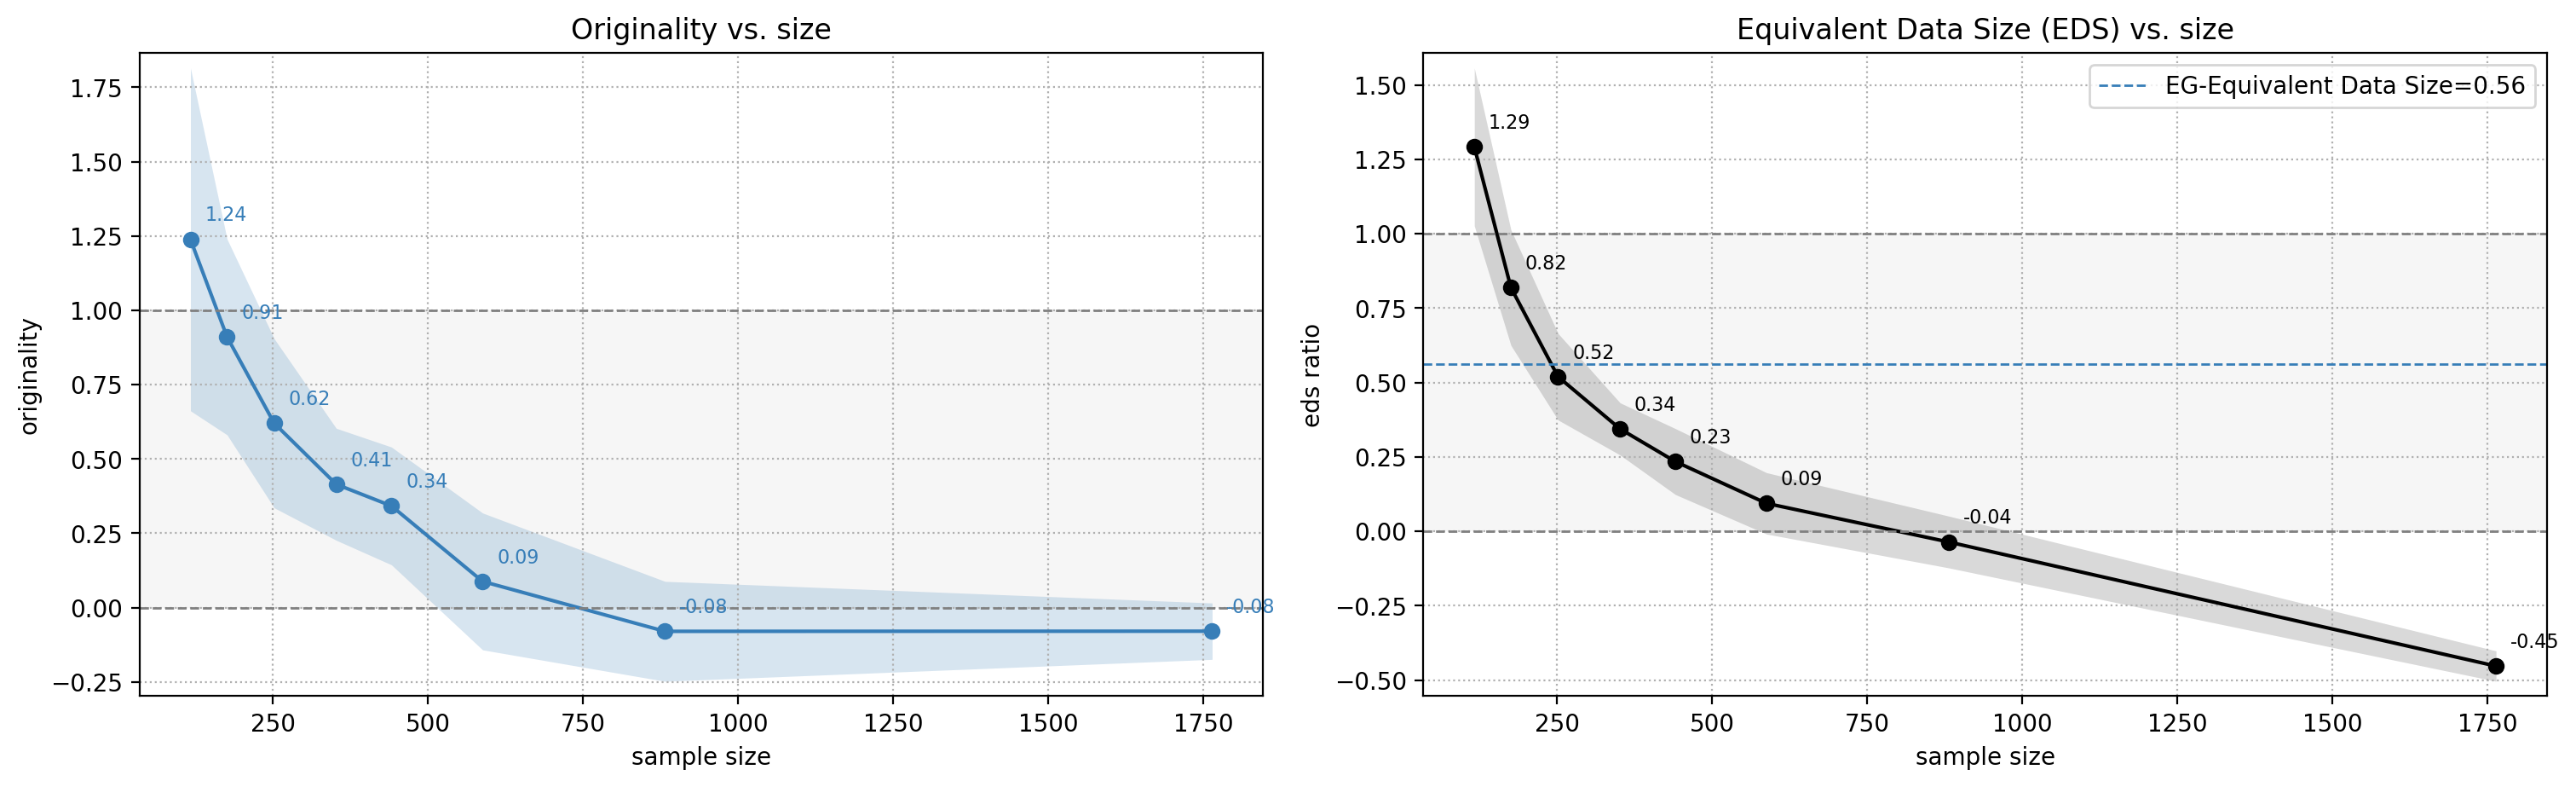

In [7]:
from abstractgraph_generative.conditional_batch import ConditionalAutoregressiveGraphsGenerator

dataset_generator = ConditionalAutoregressiveGraphsGenerator(
    generator=generator,
    graph_estimator=graph_estimator,
    constraint_level=1,
    use_context_embedding=False,
    min_cluster_size=20,
    size_factor=1,
    verbose=True,
)

generated_graphs, generated_targets = dataset_generator.generate(
    train_graphs,
    train_targets,
)

estimated_generative_quality(
    generated_graphs,
    generated_targets,
    train_graphs,
    train_targets,
    reference_graphs,
    reference_targets,
    test_graphs,
    test_targets,
)


  cluster | size |   generated |           cumulative |    elapsed |        eta
     1/56 |   33 |       3/33  |      3/1764 (  0.2%) |     33.21m |     30.44h
     2/56 |   31 |      14/31  |     17/1764 (  1.0%) |     31.22m |     28.99h
     3/56 |   39 |      21/39  |     38/1764 (  2.2%) |     34.67m |     29.10h
     4/56 |   27 |       8/27  |     46/1764 (  2.6%) |     24.54m |     25.66h
     5/56 |   29 |       8/29  |     54/1764 (  3.1%) |     26.63m |     21.75h
     6/56 |   20 |       3/20  |     57/1764 (  3.2%) |     18.27m |     18.71h
     7/56 |   20 |      20/20  |     77/1764 (  4.4%) |     13.80m |     13.09h
     8/56 |   22 |      10/22  |     87/1764 (  4.9%) |     21.59m |     14.15h
     9/56 |   53 |      10/53  |     97/1764 (  5.5%) |      1.02h |     32.42h
    10/56 |   25 |       8/25  |    105/1764 (  6.0%) |     30.74m |     35.23h
    11/56 |   47 |      11/47  |    116/1764 (  6.6%) |     47.73m |     29.43h
    12/56 |   32 |       8/32  |    124/

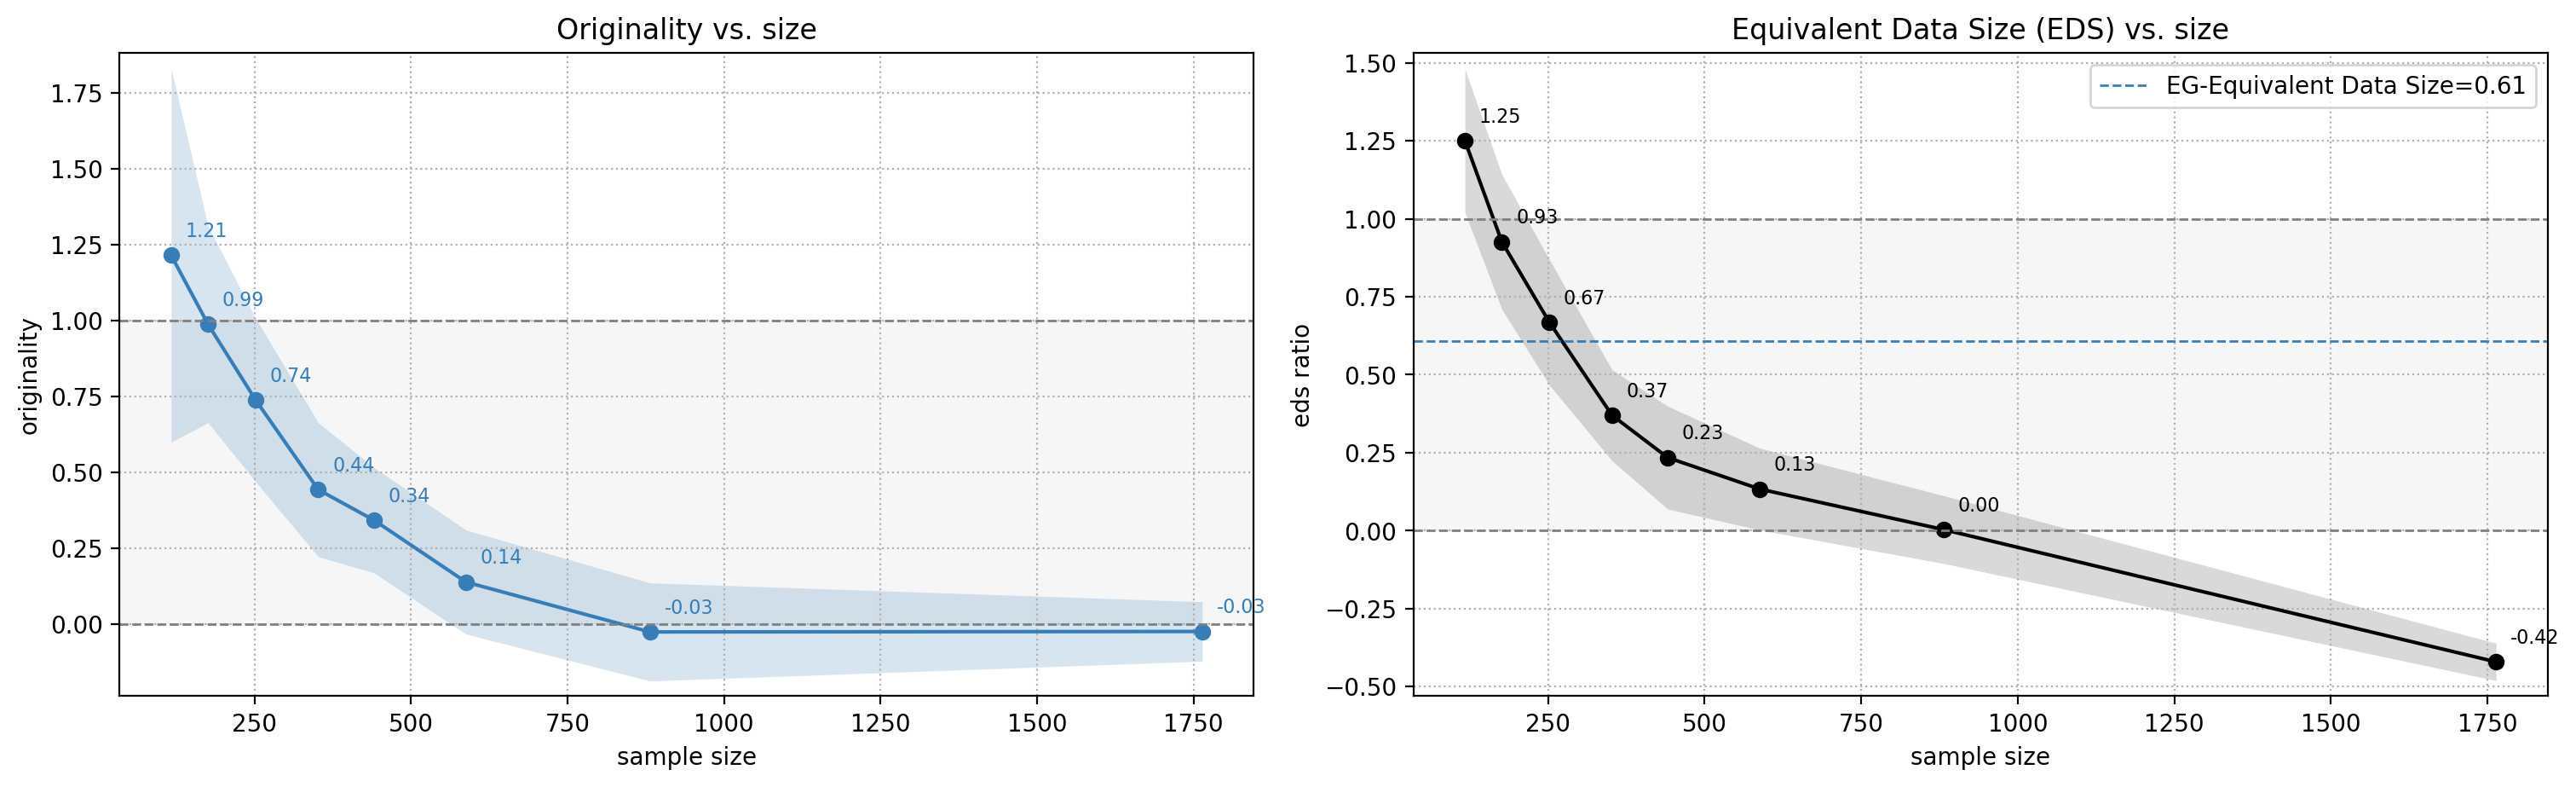

In [8]:
from abstractgraph_generative.conditional_batch import ConditionalAutoregressiveGraphsGenerator

dataset_generator = ConditionalAutoregressiveGraphsGenerator(
    generator=generator,
    graph_estimator=graph_estimator,
    constraint_level=1,
    use_context_embedding=True,
    min_cluster_size=20,
    size_factor=1,
    verbose=True,
)

generated_graphs, generated_targets = dataset_generator.generate(
    train_graphs,
    train_targets,
)

estimated_generative_quality(
    generated_graphs,
    generated_targets,
    train_graphs,
    train_targets,
    reference_graphs,
    reference_targets,
    test_graphs,
    test_targets,
)


---